In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

In [27]:
df=pd.read_csv("amazon.csv")
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [28]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [29]:
# convert rating column to numeric
df['rating']=pd.to_numeric(df['rating'],errors='coerce')

In [55]:
df["purchased"]=(df["rating"]>4).astype(int)

In [56]:
# Convert to string → remove ₹ and commas → convert to numeric
df['discounted_price'] = (
    df['discounted_price']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['discounted_price'] = pd.to_numeric(df['discounted_price'], errors='coerce')


In [57]:
df['rating'] = df['rating'].fillna(df['rating'].median())

In [58]:
# Feature and Target 
X=df[['rating','discounted_price']]
y=df['purchased']

In [59]:
# Train-Test-Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [60]:
# Scaling
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [61]:
# Apply KNN
knn=KNeighborsClassifier(n_neighbors=5,metric='euclidean')
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [62]:
# Prediction
y_pred=knn.predict(X_test)


In [63]:
# evaluation
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))

Accuracy: 0.9954545454545455
Confusion Matrix:
 [[170   2]
 [  0 268]]


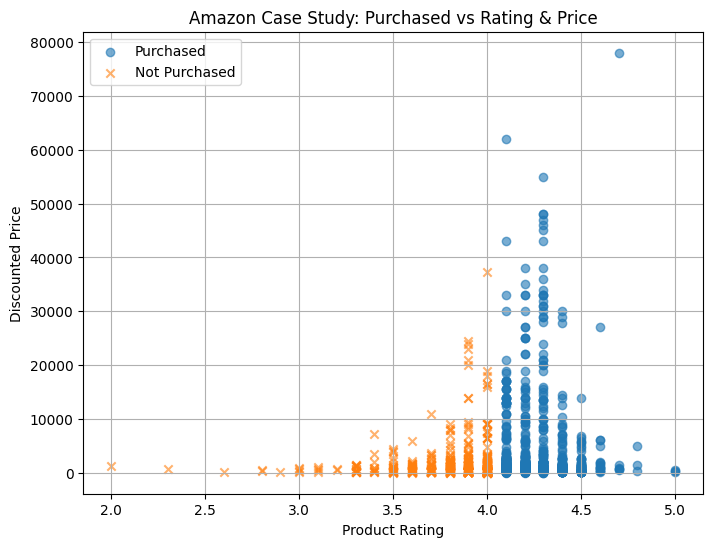

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Purchased = 1
plt.scatter(
    df[df['purchased'] == 1]['rating'],
    df[df['purchased'] == 1]['discounted_price'],
    alpha=0.6,
    label='Purchased',
    marker='o'
)

# Purchased = 0
plt.scatter(
    df[df['purchased'] == 0]['rating'],
    df[df['purchased'] == 0]['discounted_price'],
    alpha=0.6,
    label='Not Purchased',
    marker='x'
)

plt.xlabel("Product Rating")
plt.ylabel("Discounted Price")
plt.title("Amazon Case Study: Purchased vs Rating & Price")
plt.legend()
plt.grid(True)
plt.show()


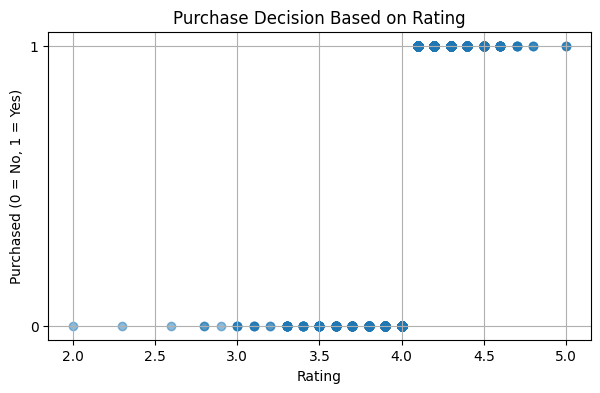

In [65]:
plt.figure(figsize=(7, 4))

plt.scatter(
    df['rating'],
    df['purchased'],
    alpha=0.5
)

plt.xlabel("Rating")
plt.ylabel("Purchased (0 = No, 1 = Yes)")
plt.title("Purchase Decision Based on Rating")
plt.yticks([0, 1])
plt.grid(True)
plt.show()


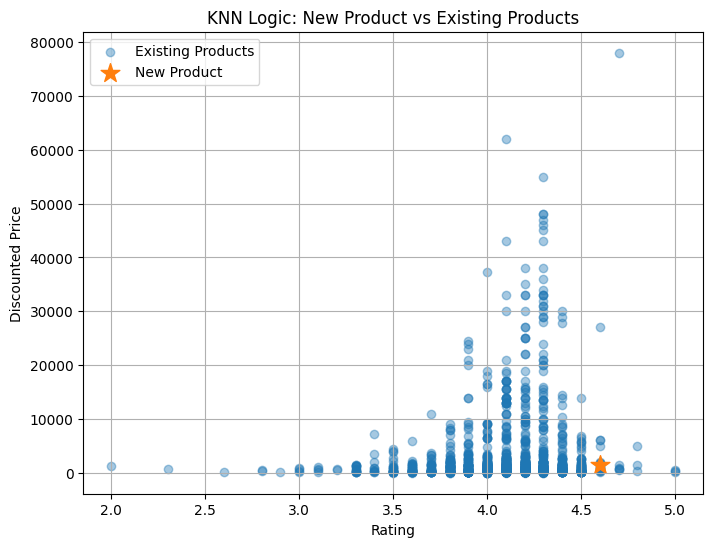

In [66]:
# Example new product
new_rating = 4.6
new_price = 1500

plt.figure(figsize=(8, 6))

plt.scatter(
    df['rating'],
    df['discounted_price'],
    alpha=0.4,
    label='Existing Products'
)

plt.scatter(
    new_rating,
    new_price,
    s=200,
    marker='*',
    label='New Product'
)

plt.xlabel("Rating")
plt.ylabel("Discounted Price")
plt.title("KNN Logic: New Product vs Existing Products")
plt.legend()
plt.grid(True)
plt.show()
